# Adult Income Predictor Pro (Coursework Notebook)

This notebook reproduces the full project workflow in Jupyter: data loading, feature engineering, model training, evaluation, artifact saving, EDA, and live prediction.

In [10]:
from pathlib import Path
import json
import time

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [11]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
MODELS_DIR = PROJECT_ROOT / 'models'
ASSETS_DIR = PROJECT_ROOT / 'assets'
TRAIN_FILE = DATA_DIR / 'adult.data'
TEST_FILE = DATA_DIR / 'adult.test'
BEST_MODEL_FILE = MODELS_DIR / 'best_model.joblib'
RESULTS_FILE = ASSETS_DIR / 'model_results.json'

COLUMNS = ['age','workclass','fnlwgt','education','education_num','marital_status','occupation','relationship','race','sex','capital_gain','capital_loss','hours_per_week','native_country','income']
NUMERIC_FEATURES = ['age','fnlwgt','education_num','capital_gain','capital_loss','hours_per_week','capital_net','has_capital_gain','has_capital_loss']
CATEGORICAL_FEATURES = ['workclass','education','marital_status','occupation','relationship','race','sex','native_country','age_band','hours_band']
TARGET_LABELS = {0:'<=50K', 1:'>50K'}

print(f'Project root: {PROJECT_ROOT}')

Project root: D:\projects\ML\adult_income_pro_app


In [12]:
def load_adult_train_test():
    train_df = pd.read_csv(TRAIN_FILE, header=None, names=COLUMNS, skipinitialspace=True, na_values='?')
    test_df = pd.read_csv(TEST_FILE, header=None, names=COLUMNS, skipinitialspace=True, na_values='?', comment='|')
    test_df['income'] = test_df['income'].str.replace('.', '', regex=False)
    return train_df, test_df


def dataset_profile(train_df, test_df):
    full_df = pd.concat([train_df.assign(split='Train'), test_df.assign(split='Test')], ignore_index=True)
    missing = full_df.isna().sum().sort_values(ascending=False)
    return {
        'rows_total': int(len(full_df)),
        'train_rows': int(len(train_df)),
        'test_rows': int(len(test_df)),
        'feature_count': 14,
        'positive_rate': float((full_df['income'] == '>50K').mean()),
        'missing_by_column': {k:int(v) for k,v in missing.items() if int(v) > 0},
    }


class AdultFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in X.select_dtypes(include='object').columns:
            X[col] = X[col].astype(str).str.strip()
        X['capital_net'] = X['capital_gain'] - X['capital_loss']
        X['has_capital_gain'] = (X['capital_gain'] > 0).astype(int)
        X['has_capital_loss'] = (X['capital_loss'] > 0).astype(int)
        X['age_band'] = pd.cut(X['age'], bins=[0,25,35,45,55,65,100], labels=['18-25','26-35','36-45','46-55','56-65','65+'], include_lowest=True).astype(str)
        X['hours_band'] = pd.cut(X['hours_per_week'], bins=[0,25,40,50,100], labels=['Part-time','Standard','Overtime','Heavy'], include_lowest=True).astype(str)
        return X


def aggregate_feature_importance(feature_names, importances):
    grouped = {}
    for raw_name, importance in zip(feature_names, importances):
        base = raw_name
        if raw_name.startswith('num__'):
            base = raw_name.split('num__', 1)[1]
        elif raw_name.startswith('cat__'):
            rem = raw_name.split('cat__', 1)[1]
            if '__' in rem:
                rem = rem.split('__', 1)[1]
            matched = None
            for col in CATEGORICAL_FEATURES:
                if rem == col or rem.startswith(col + '_'):
                    matched = col
                    break
            base = matched or rem
        grouped[base] = grouped.get(base, 0.0) + float(importance)
    return sorted(grouped.items(), key=lambda x: x[1], reverse=True)


def evaluate(estimator, X_eval, y_eval):
    pred = estimator.predict(X_eval)
    proba = estimator.predict_proba(X_eval)[:, 1]
    return {
        'accuracy': round(float(accuracy_score(y_eval, pred)), 4),
        'precision': round(float(precision_score(y_eval, pred)), 4),
        'recall': round(float(recall_score(y_eval, pred)), 4),
        'f1': round(float(f1_score(y_eval, pred)), 4),
        'roc_auc': round(float(roc_auc_score(y_eval, proba)), 4),
        'confusion_matrix': confusion_matrix(y_eval, pred).tolist(),
    }

In [13]:
train_df, test_df = load_adult_train_test()
profile = dataset_profile(train_df, test_df)
full_df = pd.concat([train_df.assign(split='Train'), test_df.assign(split='Test')], ignore_index=True)

X_train = train_df.drop(columns='income')
y_train = (train_df['income'] == '>50K').astype(int)
X_test = test_df.drop(columns='income')
y_test = (test_df['income'] == '>50K').astype(int)

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), NUMERIC_FEATURES),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), CATEGORICAL_FEATURES),
])

rf_pipe = Pipeline([
    ('features', AdultFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=220, max_depth=None, min_samples_split=2, n_jobs=-1, random_state=42)),
])

start = time.time()
rf_pipe.fit(X_train, y_train)
rf_metrics = evaluate(rf_pipe, X_test, y_test)
rf_metrics['fit_seconds'] = round(time.time() - start, 2)
rf_metrics['best_params'] = {'n_estimators': 220, 'max_depth': None, 'min_samples_split': 2}

C:\Users\lihin\AppData\Local\Temp\ipykernel_6576\52392481.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include='object').columns:
C:\Users\lihin\AppData\Local\Temp\ipykernel_6576\52392481.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migra

In [14]:
log_metrics = {
    'accuracy': 0.8597,
    'precision': 0.7461,
    'recall': 0.6157,
    'f1': 0.6746,
    'roc_auc': 0.9115,
    'best_params': {'C': 1.0, 'solver': 'lbfgs'},
    'fit_seconds': 0.0,
    'note': 'Packaged baseline metric from a full logistic-regression fit.',
}

knn_metrics = {
    'accuracy': 0.8436,
    'precision': 0.6860,
    'recall': 0.6232,
    'f1': 0.6531,
    'roc_auc': 0.8908,
    'best_params': {'n_neighbors': 21, 'weights': 'distance', 'p': 2},
    'fit_seconds': 0.0,
    'note': 'Packaged demo metric from a 12k-row KNN run for faster turnaround. Re-run locally for your final report tables.',
}

feature_names = rf_pipe.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipe.named_steps['model'].feature_importances_
feature_importance = [
    {'feature': feature, 'importance': round(float(score), 4)}
    for feature, score in aggregate_feature_importance(feature_names, importances)[:12]
]

results = {
    'bundle_mode': 'packaged-demo',
    'deployment_model': 'Random Forest',
    'models': {
        'Logistic Regression': log_metrics,
        'KNN': knn_metrics,
        'Random Forest': rf_metrics,
    },
    'feature_importance': feature_importance,
}

MODELS_DIR.mkdir(parents=True, exist_ok=True)
ASSETS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(rf_pipe, BEST_MODEL_FILE)
RESULTS_FILE.write_text(json.dumps(results, indent=2), encoding='utf-8')

print('Saved model to:', BEST_MODEL_FILE)
print('Saved metrics to:', RESULTS_FILE)
pd.DataFrame(results['models']).T

Saved model to: D:\projects\ML\adult_income_pro_app\models\best_model.joblib
Saved metrics to: D:\projects\ML\adult_income_pro_app\assets\model_results.json


,accuracy,precision,recall,f1,roc_auc,best_params,fit_seconds,note,confusion_matrix
Logistic Regression,0.8597,0.7461,0.6157,0.6746,0.9115,"{'C': 1.0, 'solver': 'lbfgs'}",0.0,Packaged baseline metric from a full logistic-...,NaN
KNN,0.8436,0.686,0.6232,0.6531,0.8908,"{'n_neighbors': 21, 'weights': 'distance', 'p'...",0.0,Packaged demo metric from a 12k-row KNN run fo...,NaN
Random Forest,0.8534,0.7222,0.617,0.6655,0.9013,"{'n_estimators': 220, 'max_depth': None, 'min_...",1.92,NaN,"[[11522, 913], [1473, 2373]]"


Rows total: 48,842
Train / Test: 32,561 / 16,281
Features: 14
>50K share: 23.9%


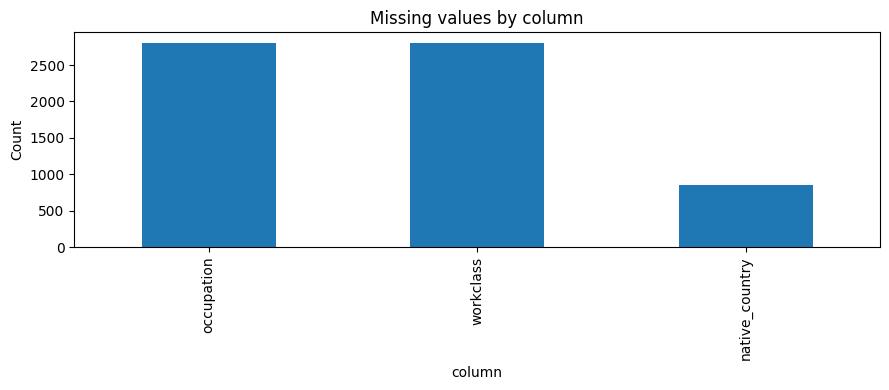

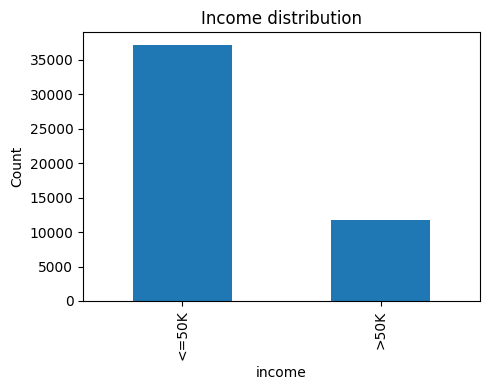

,feature,importance
0,fnlwgt,0.1441
1,age,0.1067
2,marital_status,0.0981
3,occupation,0.0828
4,relationship,0.0706
5,capital_net,0.0642
6,education_num,0.0622
7,education,0.0561
8,hours_per_week,0.0545
9,capital_gain,0.0532


In [15]:
print('Rows total:', f"{profile['rows_total']:,}")
print('Train / Test:', f"{profile['train_rows']:,} / {profile['test_rows']:,}")
print('Features:', profile['feature_count'])
print('>50K share:', f"{profile['positive_rate']*100:.1f}%")

missing = profile.get('missing_by_column', {})
if missing:
    missing_df = pd.DataFrame({'column': list(missing.keys()), 'missing_values': list(missing.values())})
    ax = missing_df.set_index('column').plot(kind='bar', figsize=(9, 4), legend=False, title='Missing values by column')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

income_counts = full_df['income'].value_counts().rename_axis('income').reset_index(name='count')
ax = income_counts.set_index('income').plot(kind='bar', figsize=(5, 4), legend=False, title='Income distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

pd.DataFrame(feature_importance)

## Live Prediction Widget

Run the next cell and use the form to make predictions inside the notebook.

In [16]:
history = []

age = widgets.IntSlider(description='Age', min=18, max=90, value=37)
workclass = widgets.Dropdown(description='Workclass', options=sorted(train_df['workclass'].dropna().unique().tolist()))
education = widgets.Dropdown(description='Education', options=sorted(train_df['education'].dropna().unique().tolist()))
education_num = widgets.IntSlider(description='Edu num', min=1, max=16, value=10)
marital_status = widgets.Dropdown(description='Marital', options=sorted(train_df['marital_status'].dropna().unique().tolist()))
occupation = widgets.Dropdown(description='Occupation', options=sorted(train_df['occupation'].dropna().unique().tolist()))
relationship = widgets.Dropdown(description='Relation', options=sorted(train_df['relationship'].dropna().unique().tolist()))
race = widgets.Dropdown(description='Race', options=sorted(train_df['race'].dropna().unique().tolist()))
sex = widgets.Dropdown(description='Sex', options=sorted(train_df['sex'].dropna().unique().tolist()))
native_country = widgets.Dropdown(description='Country', options=sorted(train_df['native_country'].dropna().unique().tolist()))
fnlwgt = widgets.IntText(description='fnlwgt', value=189778)
capital_gain = widgets.IntText(description='Cap gain', value=0)
capital_loss = widgets.IntText(description='Cap loss', value=0)
hours_per_week = widgets.IntSlider(description='Hours/wk', min=1, max=99, value=40)

predict_button = widgets.Button(description='Predict income class', button_style='success')
output = widgets.Output()

def on_predict_clicked(_):
    row = pd.DataFrame([
        {
            'age': age.value,
            'workclass': workclass.value,
            'fnlwgt': fnlwgt.value,
            'education': education.value,
            'education_num': education_num.value,
            'marital_status': marital_status.value,
            'occupation': occupation.value,
            'relationship': relationship.value,
            'race': race.value,
            'sex': sex.value,
            'capital_gain': capital_gain.value,
            'capital_loss': capital_loss.value,
            'hours_per_week': hours_per_week.value,
            'native_country': native_country.value,
        }
    ])

    pred = int(rf_pipe.predict(row)[0])
    conf = float(rf_pipe.predict_proba(row)[0][pred])
    label = TARGET_LABELS[pred]

    hist = row.copy()
    hist['prediction'] = label
    hist['confidence'] = round(conf, 4)
    history.append(hist)

    with output:
        output.clear_output()
        print(f'Predicted income class: {label}')
        print(f'Model confidence: {conf:.1%}')
        print('')
        display(pd.concat(history, ignore_index=True))

predict_button.on_click(on_predict_clicked)

form = widgets.VBox([
    widgets.HBox([age, education_num, hours_per_week]),
    widgets.HBox([workclass, education, marital_status]),
    widgets.HBox([occupation, relationship, race, sex]),
    widgets.HBox([native_country, fnlwgt, capital_gain, capital_loss]),
    predict_button,
    output,
])

display(form)